## 1) IMPORTING DATASET AND CLEANING DATA

In [1]:
import pandas as pd

df = pd.read_csv("../data/german_credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [2]:
df.shape

(1000, 11)

In [3]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [4]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

FROM ABOVE OUTPUT- we saw savings accounts and checking account has missing values. we will remove them

In [5]:
df["Saving accounts"].value_counts(dropna=False)

Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Keep missing as its own category.

Why?

In banking data:

little savings
moderate savings
rich savings
unknown savings

can all convey different information.

We're building a risk model, so we would rather preserve information than guess.

In [6]:
df["Saving accounts"] = df["Saving accounts"].fillna("unknown")

DOING SAME PROCESS FOR Checking accounts

In [7]:
df["Checking account"].value_counts(dropna=False)

Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

Notice that NaN is the largest group.
So instead of replacing NaN with "little" (mode), we'll treat missing as its own category.

This is because - Sometimes missing data itself contains information.

Example:
Customer has a checking account → information exists 

Customer has no checking account recorded → also information

In [8]:
df["Checking account"] = df["Checking account"].fillna("unknown")

In [9]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

REMOVE USELESS COLUMNS

In [10]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [11]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [12]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

IT TELLS 70% LOANS ARE GOOD  AND 30 % ARE BAD

## 2) SEPERATE FEATURES AND TARGET

In [13]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

print(X.shape)
print(y.shape)

(1000, 9)
(1000,)


## 3)ENCODE CATEGORICAL COLUMNS

In [14]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(1000, 21)

In [15]:
y = y.map({"good": 1,"bad": 0})

## 4) TRAIN TEST SPLIT

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [17]:
print(X_train.shape)
print(X_test.shape)

(800, 21)
(200, 21)


## 5) TRAIN FIRST MODEL

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = ["Age", "Credit amount", "Duration"]

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test_scaled[numeric_cols] = scaler.transform( X_test[numeric_cols])

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = model.predict(X_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.75


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.36      0.46        59
           1       0.77      0.91      0.84       141

    accuracy                           0.75       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.73      0.75      0.73       200



Accuracy when seen in first glance looks good - 75%. 
But What does Recall = 0.36 mean?

Out of 59 actual bad customers:

Model correctly identified ≈ 21
Missed ≈ 38

That's not good.

In a bank:

Missing a bad customer is expensive.



Good Risk Customers (Class 1)
Precision = 0.77
Recall    = 0.91
F1 Score  = 0.84

The model is heavily biased toward predicting customers as good.

This is common because:

700 good
300 bad

The dataset is imbalanced.

## 6) TRAINING A RANDOM FOREST

Random Forest combines many decision trees and lets them vote.
This usually captures complex patterns better than Logistic Regression.

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,random_state=42)


In [24]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
rf_pred = rf.predict(X_test)

In [26]:
print(accuracy_score(y_test, rf_pred))

0.74


In [27]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.59      0.41      0.48        59
           1       0.78      0.88      0.83       141

    accuracy                           0.74       200
   macro avg       0.68      0.64      0.65       200
weighted avg       0.72      0.74      0.72       200



Random Forest has slightly lower accuracy.
But it catches more bad customers (Recall 0.41 vs 0.36).

## 7) ANALYSING MODEL DECISION USING FEATURE IMPORTANCE

In [28]:
importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values( by="Importance", ascending=False)
print(importance.head(10))

                      Feature  Importance
2               Credit amount    0.228043
0                         Age    0.180058
3                    Duration    0.155273
13   Checking account_unknown    0.076996
1                         Job    0.058355
4                    Sex_male    0.033542
10    Saving accounts_unknown    0.030594
14                Purpose_car    0.028257
11  Checking account_moderate    0.027748
5                 Housing_own    0.027326


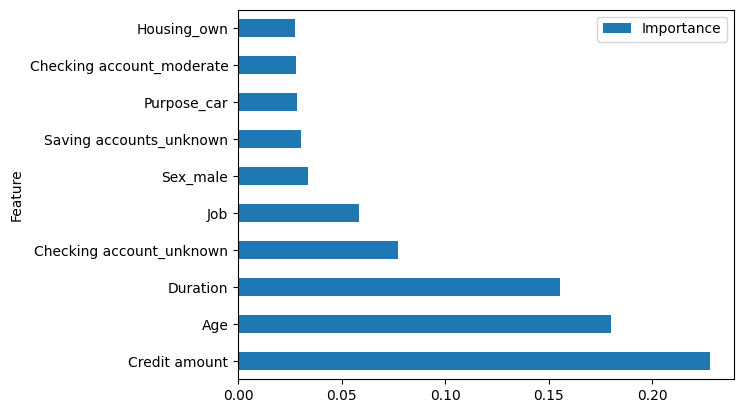

In [29]:
import matplotlib.pyplot as plt
importance.head(10).plot(x="Feature",y="Importance",kind="barh")
plt.show()

The top factors influencing risk are:

Rank	Feature

1.	    Credit amount

2.      Age

3.	    Duration

4.	    Checking account_unknown

5.	    Job

The model is basically saying:
Larger loans matter a lot.
Longer repayment duration matters.
Customer age matters.
Banking history matters.
Employment/job category matters.

Important Insight from Checking account_unknown feature - model is telling us:
Missing checking-account information carries predictive value.

## 8) SHAP EXPLAINER

Moving from: What features matter overall? to  Why was This customer predicted as risky?

In [30]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

c:\Users\YAMINI SAHU\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
type(shap_values)

numpy.ndarray

In [33]:
shap_values.shape

(200, 21, 2)

Shape value tells - 
200 test samples
21 features
2 classes (good/bad)

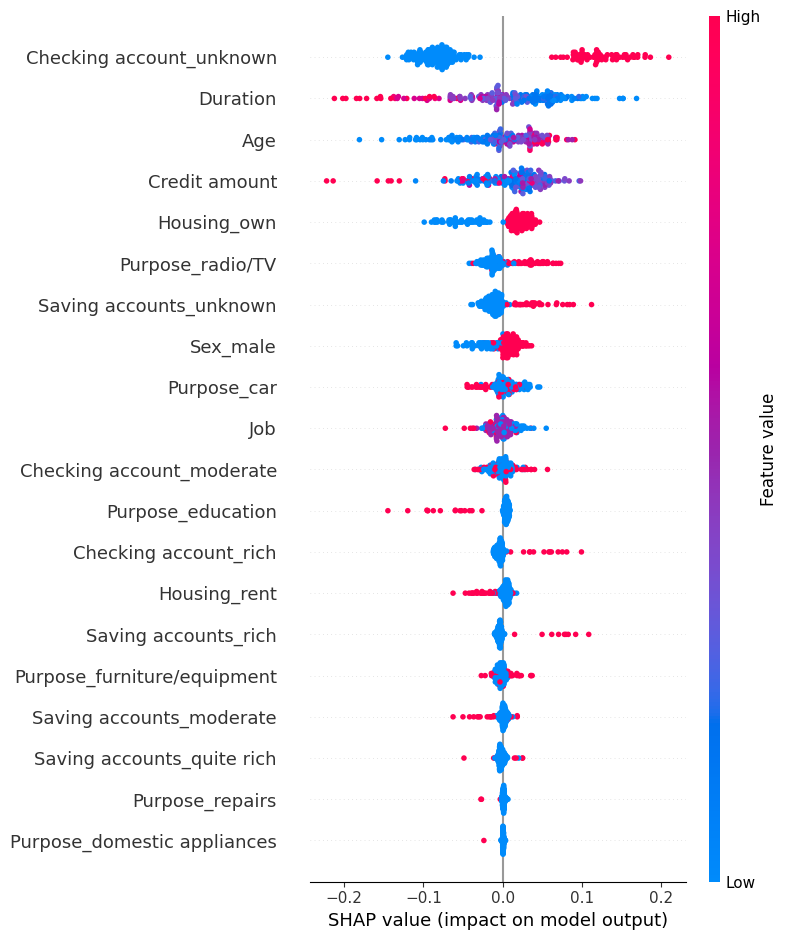

In [34]:
shap.summary_plot(shap_values[:, :, 1],X_test)

Right side (+ SHAP value) → pushes prediction toward Good Risk

Left side (- SHAP value) → pushes prediction toward Bad Risk

Red = High feature value

Blue = Low feature value

OBSERVATIONS                                 
1) DURATION : High Duration (red) Mostly on left side

   Interpretation: Longer loan duration tends to increase risk.

   Business reasoning:If someone needs a long time to repay, there's greater uncertainty and higher default probability.

2) AGE: Older age (red) Mostly right side

   Interpretation: Older customers are generally predicted as safer borrowers.

   Possible reason: Stable income, Stable employment, Better financial history

3) CREDIT AMOUNT:Large loan amount (red)appears on both sides but often contributes toward risk.

   Interpretation: Credit Amount is one of the most important features influencing credit risk predictions. However, SHAP shows that its effect is not consistently positive or negative. High credit amounts sometimes push predictions toward good risk and sometimes toward bad risk, indicating that the model considers credit amount together with other factors such as age, duration, and account information rather than in isolation.

4) Checking Account Unknown: It is the most influential categorical feature.

   Interpretation: "Treating missing checking-account information as a separate category proved useful. SHAP analysis showed that the 'checking account unknown' category carried predictive information and often contributed positively toward good-risk predictions."

5) Saving Accounts Unknown: Missing saving-account information also appeared to influence predictions, though less strongly than checking-account status.

6) Housing Own: Customers who owned their homes tended to receive slightly positive contributions toward good-risk predictions.



## 9) LOCAL EXPLAINABILITY

In [35]:
explainer.expected_value

array([0.30109375, 0.69890625])

It means: Class 0 (bad)  -> 30.1%,  Class 1 (good) -> 69.9%

This is the base prediction before looking at any customer.

In simple terms: If I know nothing about a customer, the model starts by assuming roughly a 70% chance of good risk.

In [36]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

# 11)  SHAP LOCAL EXPLAINER

In [37]:
rf.predict(X_test.iloc[[0]])

array([1])

In [38]:
rf.predict_proba(X_test.iloc[[0]])

array([[0.115, 0.885]])

Value	                    Meaning

0.699	       -   Average probability of Good Risk before seeing any customer

0.885	       -   Probability of Good Risk for Customer #0

predict()	   -    Returns class (0 or 1)

predict_proba() -  Returns probabilities for all classes

expected_value	-  SHAP baseline from which feature contributions are added/subtracted


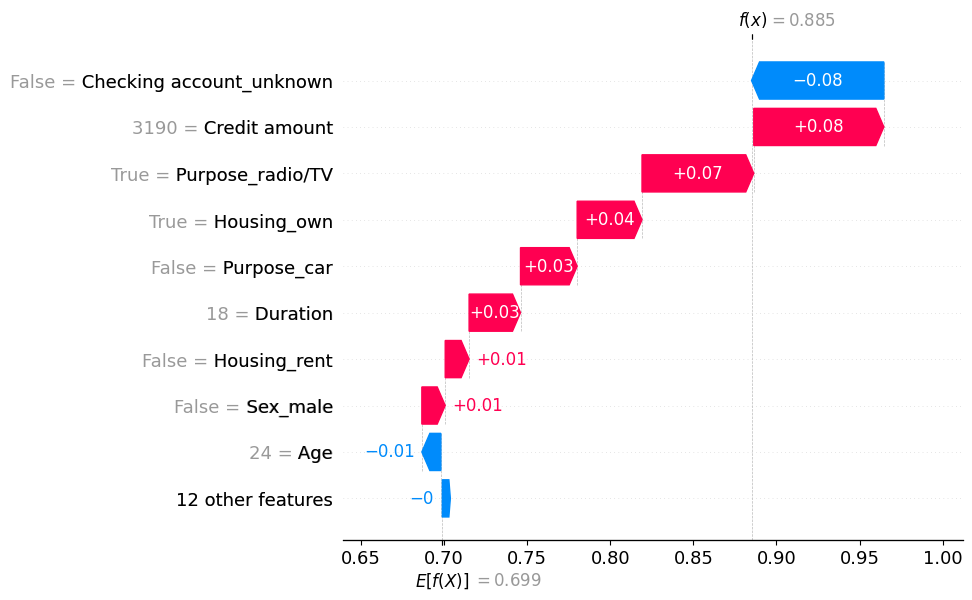

In [39]:
shap.plots.waterfall(shap.Explanation(values=shap_values[0,:,1], base_values=explainer.expected_value[1], data=X_test.iloc[0],
    feature_names=X_test.columns))

 The model starts from: Base Probability = 0.699(Got from expected class 1 )

 It means Before seeing any customer information, the model expects about a 69.9% chance of Good Risk. Then features move the prediction up or down.

 Final prediction:

 Good Risk = 0.885(Got from rf proba expected class 1)
 Customer-Level Interpretation
 
 Positive Contributors (toward Good Risk)
 
  1) Credit Amount = 3190,  Contribution ≈ +0.08

   For this customer, this loan amount increased confidence in Good Risk.

   Notice how this differs from our global SHAP discussion: Credit Amount is not always good or bad. For THIS customer, it helped.

  2) Purpose = radio/TV, Contribution ≈ +0.07

     This loan purpose pushed prediction toward Good Risk.

  
  3) Housing Own = True, Contribution ≈ +0.04

     Owning a house increased confidence in repayment ability. This aligns with our global SHAP observation.

  4) Duration = 18, Contribution ≈ +0.03

     Globally we observed: Longer durations increase risk.
     
     But this customer's duration is only 18 months. So here it contributes positively.
     
     Excellent example of global vs local explanation.

Negative Contributors

  1) Checking Account Unknown = False, Contribution ≈ -0.08

     This is the strongest negative factor.
     
   Global SHAP observation: "Checking account unknown" often pushed predictions toward Good Risk. This customer does not belong to that category. Therefore the prediction lost some confidence. This is perfectly consistent with the global plot.

  2) Age = 24, Contribution ≈ -0.01
    
     Small negative effect.

   Earlier we observed: Older customers tended to look safer.A relatively young customer slightly reduced confidence. Again, consistent with global SHAP.


"The model started from a baseline good-risk probability of 69.9%. The prediction increased to 88.5% primarily due to factors such as a moderate credit amount, home ownership, a shorter loan duration, and the loan purpose category. The main factor reducing confidence was the customer's checking-account status. SHAP enabled me to quantify how each feature contributed to the final decision, making the Random Forest model interpretable at the individual-customer level."

# 12) COMPARISON OF SAFEST AND RISKIEST CUSTOMER

Customer 10 → Highest Good Risk probability among those 20

Customer 13 → Lowest Good Risk probability among those 20

In [47]:
customer = X_test.iloc[[10]]
shap_values = explainer(customer)

In [48]:
print(shap_values.values.shape)

(1, 21, 2)


In [49]:
prediction = rf.predict(customer)[0]
print(prediction)

1


In [50]:
customer_shap = shap_values.values[0, :, prediction]

In [51]:
explanation = pd.DataFrame({"Feature": X_test.columns, "SHAP Value": customer_shap})

In [54]:
explanation["Absolute"] = explanation["SHAP Value"].abs()

explanation = explanation.sort_values(by="Absolute", ascending=False)

In [55]:
explanation.head(10)

,Feature,SHAP Value,Absolute
3,Duration,0.116284,0.116284
18,Purpose_radio/TV,0.056386,0.056386
13,Checking account_unknown,-0.043637,0.043637
5,Housing_own,0.035976,0.035976
14,Purpose_car,0.030123,0.030123
1,Job,0.023418,0.023418
11,Checking account_moderate,0.009928,0.009928
2,Credit amount,0.009147,0.009147
7,Saving accounts_moderate,0.008123,0.008123
16,Purpose_education,0.007113,0.007113


In [57]:
explanation["Impact"] = explanation["SHAP Value"].apply(
    lambda x: "⬆ Increased predicted class" if x > 0 else "⬇ Decreased predicted class"
)

explanation[["Feature", "SHAP Value", "Impact"]].head(5)

,Feature,SHAP Value,Impact
3,Duration,0.116284,⬆ Increased predicted class
18,Purpose_radio/TV,0.056386,⬆ Increased predicted class
13,Checking account_unknown,-0.043637,⬇ Decreased predicted class
5,Housing_own,0.035976,⬆ Increased predicted class
14,Purpose_car,0.030123,⬆ Increased predicted class


In [56]:
y_test.iloc[10]

np.int64(1)

In [42]:
X_test.iloc[13]

Age                               36
Job                                2
Credit amount                   7297
Duration                          60
Sex_male                        True
Housing_own                    False
Housing_rent                    True
Saving accounts_moderate       False
Saving accounts_quite rich     False
Saving accounts_rich           False
Saving accounts_unknown        False
Checking account_moderate      False
Checking account_rich          False
Checking account_unknown       False
Purpose_car                    False
Purpose_domestic appliances    False
Purpose_education              False
Purpose_furniture/equipment    False
Purpose_radio/TV               False
Purpose_repairs                False
Purpose_vacation/others        False
Name: 973, dtype: object

In [43]:
y_test.iloc[13]

np.int64(0)

SAFEST VS RISKIEST CUSTOMER -

The model assigned higher risk to customers with longer repayment durations(60 months over 6 months ) and larger credit amounts, while customers with shorter durations and smaller loan amounts were generally classified as safer borrowers.

SAVING COLUMN NAMES

In [44]:
X.columns.tolist()

['Age',
 'Job',
 'Credit amount',
 'Duration',
 'Sex_male',
 'Housing_own',
 'Housing_rent',
 'Saving accounts_moderate',
 'Saving accounts_quite rich',
 'Saving accounts_rich',
 'Saving accounts_unknown',
 'Checking account_moderate',
 'Checking account_rich',
 'Checking account_unknown',
 'Purpose_car',
 'Purpose_domestic appliances',
 'Purpose_education',
 'Purpose_furniture/equipment',
 'Purpose_radio/TV',
 'Purpose_repairs',
 'Purpose_vacation/others']

In [45]:
feature_columns = X.columns.tolist()

In [46]:
joblib.dump(feature_columns, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [ ]:
prediction = rf.predict(customer)[0]
print(prediction)